<a href="https://colab.research.google.com/github/hechoii/AI_Practice/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets evaluate
!pip install fiftyone
!pip install -q regex tqdm
!pip install -q -U xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.5/934.5 kB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.3 MB/s eta 0

In [ ]:
!pip install tf-keras

In [ ]:
!pip uninstall -y transformers
!pip install transformers==4.39.0 tf-keras

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers

In [ ]:
import tensorflow as tf### models
import numpy as np### math computations
import matplotlib.pyplot as plt### plotting bar chart
import os
import fiftyone as fo
import shutil
import pandas as pd
import cv2
import random
import hashlib
from PIL import Image
import albumentations as A
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from transformers import TFSegformerForSemanticSegmentation
from transformers import create_optimizer
import torch
import numpy as np
from diffusers.utils import load_image, make_image_grid
import torch
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import cv2
from IPython.display import display
from matplotlib import pyplot as plt
import numpy as np
import copy
#from diffusers import StableDiffusionInpaintPipeline, EulerDiscreteScheduler

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#model_path = "/content/drive/MyDrive/Model_Segmentation/segformer_b5_clothing.h5"

# Gọi model từ thư mục Drive
#model = TFSegformerForSemanticSegmentation.from_pretrained(model_path)

KAGGLE

In [ ]:
!pip install -q kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d rajkumarl/people-clothing-segmentation

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rajkumarl/people-clothing-segmentation
License(s): CC0-1.0
100% 616M/616M [00:40<00:00, 15.9MB/s]



In [ ]:
!unzip "/content/people-clothing-segmentation.zip" -d "/content/dataset/"

Archive:  /content/people-clothing-segmentation.zip
  inflating: /content/dataset/jpeg_images/IMAGES/img_0001.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0002.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0003.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0004.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0005.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0006.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0007.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0008.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0009.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0010.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0011.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0012.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0013.jpeg  
  inflating: /content/dataset/jpeg_images/IMAGES/img_0014.jpeg  
  inflating: /content/dataset/jpeg_ima

SPLIT DATA

In [ ]:
!mkdir /content/val_dataset/
!mkdir /content/val_dataset/png_images/
!mkdir /content/val_dataset/png_masks/
!mkdir /content/val_dataset/png_images/IMAGES/
!mkdir /content/val_dataset/png_masks/MASKS/


In [ ]:
im_path = "/content/dataset/png_images/IMAGES/"
mask_path = "/content/dataset/png_masks/MASKS/"

val_im_path = "/content/val_dataset/png_images/IMAGES/"
val_mask_path = "/content/val_dataset/png_masks/MASKS/"

In [ ]:
for fname in os.listdir(mask_path):
  os.rename(mask_path+fname,mask_path+"img"+fname[3:])

In [ ]:
val_list=["0115","0025","0010","0003","0125","0200","0515","0225","0805","0915","0630","0301","0112","0905","0823","0527","0088","0055","0018",
          "0222","0049","0273","0299","0282","0372","0027","0445","0582","0374","0956","0211","0019","0961","0397","0699","0789","0996","0290",
          "0110","0315","0335","0419","0666","0525","0927","0555","0275","0855","0815","0130","0371","0412","0105","0423","0507","0028","0035","0118",
          "0232","0849","0673","0688","0777","0472","0991","0485","0592","0334","0827","0651","0619","0567","0393","0609","0719","0916","0190",
          ]

In [ ]:
for name in val_list:
  shutil.move(im_path + "img_" + name + ".png", val_im_path + "img_" + name + ".png")
  shutil.move(mask_path + "img_" + name + ".png", val_mask_path + "img_" + name + ".png")

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/png_images/IMAGES/img_0115.png'

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    ([im_path+i for i in os.listdir(im_path)],
    [mask_path+"img"+i[3:] for i in os.listdir(im_path)])
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    ([val_im_path+i for i in os.listdir(val_im_path)],
    [val_mask_path+"img"+i[3:] for i in os.listdir(val_im_path)])
)

In [ ]:
for i in train_dataset.take(3):
  print(i)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/png_images/IMAGES/img_0381.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/png_masks/MASKS/img_0381.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/png_images/IMAGES/img_0255.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/png_masks/MASKS/img_0255.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/png_images/IMAGES/img_0465.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/png_masks/MASKS/img_0465.png'>)


In [ ]:
for i in val_dataset.take(3):
  print(i)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/val_dataset/png_images/IMAGES/img_0927.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/content/val_dataset/png_masks/MASKS/img_0927.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/val_dataset/png_images/IMAGES/img_0028.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/content/val_dataset/png_masks/MASKS/img_0028.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/val_dataset/png_images/IMAGES/img_0567.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/content/val_dataset/png_masks/MASKS/img_0567.png'>)


In [ ]:
len(train_dataset), len(val_dataset)

(923, 77)

PROCESS DATA

In [ ]:
MEAN = [123.675, 116.28, 103.53]
STD = [58.395, 57.12, 57.375]


In [ ]:
def preprocess(im_path, mask_path):
  img = tf.io.decode_jpeg(tf.io.read_file(im_path))
  img = tf.cast(img, tf.float32)
  img = (img-MEAN)/STD

  mask = tf.io.decode_jpeg(tf.io.read_file(mask_path))
  mask = tf.cast(tf.squeeze(mask,-1), tf.float32)

  return img, mask

In [ ]:
pre_train_dataset = (
    train_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
)

pre_val_dataset = (
    val_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
)

In [ ]:
for i, j in pre_train_dataset.take(1):
  print(i,j)

tf.Tensor(
[[[-1.2787911 -1.3879552 -1.4384314]
  [-1.2787911 -1.3879552 -1.4384314]
  [-1.2787911 -1.3879552 -1.4384314]
  ...
  [ 1.1700487  1.3606443  1.55939  ]
  [ 1.152924   1.3431373  1.5419608]
  [ 1.152924   1.3431373  1.5419608]]

 [[-1.2787911 -1.3879552 -1.4384314]
  [-1.2787911 -1.3879552 -1.4384314]
  [-1.2787911 -1.3879552 -1.4384314]
  ...
  [ 1.2042983  1.3956583  1.5942484]
  [ 1.1700487  1.3606443  1.55939  ]
  [ 1.1700487  1.3606443  1.55939  ]]

 [[-1.2787911 -1.3879552 -1.4384314]
  [-1.2787911 -1.3879552 -1.4384314]
  [-1.2787911 -1.3879552 -1.4384314]
  ...
  [ 1.2727972  1.4656863  1.6639651]
  [ 1.2042983  1.3956583  1.5942484]
  [ 1.1871735  1.3781513  1.5768192]]

 ...

 [[ 1.2556725  1.4131653  1.6291068]
  [ 1.2385478  1.3956583  1.5768192]
  [ 1.221423   1.3781513  1.5942484]
  ...
  [ 1.4097953  1.6232493  1.9254031]
  [ 1.4097953  1.6232493  1.9254031]
  [ 1.3755457  1.5882354  1.8905447]]

 [[ 1.3926705  1.5532213  1.8033987]
  [ 1.2727972  1.4306723  

Data Augmentation

In [ ]:
H, W = 512, 512

In [ ]:
transform  = A.Compose([
    A.RandomCrop(H, W, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Transpose(p=0.5),
    A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.7),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.3), contrast_limit=(-0.3, 0.3), p=0.5),
    #A.Resize(H, W)
])

val_transform = A.Compose([
    A.Resize(H, W)
])

/tmp/ipykernel_18339/125082244.py:7: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_lower=1, num_shadows_upper=2, shadow_dimension=5, p=0.5),


In [ ]:
def aug_data(image, mask):
  aug = transform(image = image, mask = mask)
  return [ tf.convert_to_tensor(aug["image"], dtype=tf.float32),
           tf.convert_to_tensor(aug["mask"], dtype=tf.float32) ]

def val_aug_data(val_image, val_mask):
  aug = val_transform(image = val_image, mask = val_mask)
  return [ tf.convert_to_tensor(aug["image"], dtype=tf.float32),
           tf.convert_to_tensor(aug["mask"], dtype=tf.float32) ]


In [ ]:
def augment(image, mask):
  aug_output = tf.numpy_function(func=aug_data, inp=[image, mask], Tout=[tf.float32, tf.float32])
  return {"pixel_values":tf.transpose(aug_output[0],(2,0,1)), "labels":aug_output[1]}

def val_augment(val_image, val_mask):
  val_aug_output = tf.numpy_function(func=val_aug_data, inp=[val_image, val_mask], Tout=[tf.float32, tf.float32])
  return {"pixel_values":tf.transpose(val_aug_output[0],(2,0,1)), "labels":val_aug_output[1]}

In [ ]:
BATCH_SIZE = 2

train_ds = (
    pre_train_dataset
    .shuffle(10)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    pre_val_dataset
    .map(val_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
for i in train_ds.take(1):
  print(i)

{'pixel_values': <tf.Tensor: shape=(2, 3, 512, 512), dtype=float32, numpy=
array([[[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.46123764,
          0.        , 0.26379505],
         [0.        , 0.        , 0.        , ..., 1.        ,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 1.        ],
         [0.        , 0.        , 0.        , ..., 0.21685077,
          0.        , 1.        ],
         [0.        , 0.        , 0.        , ..., 0.89947414,
          0.        , 0.717901  ]],

        [[0.        , 0.        , 0.        , ..., 0.0994639 ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.6387506 ,
          0.        , 0.43690076],
         [0.        , 0.        , 0.        , ..., 1.        ,
          0.        , 0.0339471 ],
         ...,
         [0. 

In [ ]:
for i in val_ds.take(1):
  print(i)

{'pixel_values': <tf.Tensor: shape=(2, 3, 512, 512), dtype=float32, numpy=
array([[[[ 0.947818  ,  1.0185231 ,  1.1108955 , ...,  0.33833918,
           0.28851116,  0.24031562],
         [ 0.75950235,  0.8978139 ,  1.0409725 , ...,  0.39659187,
           0.3661553 ,  0.2963853 ],
         [ 0.96488744,  0.97831124,  1.0318133 , ...,  0.504832  ,
           0.40294147,  0.27402866],
         ...,
         [-0.42158338, -0.4225906 , -0.43212947, ..., -0.42869085,
          -0.42151266, -0.41283578],
         [-0.45538136, -0.4555396 , -0.45971653, ..., -0.47310433,
          -0.45444483, -0.4360491 ],
         [-0.42778778, -0.4283705 , -0.4352284 , ..., -0.45048267,
          -0.42054912, -0.40082964]],

        [[ 0.888355  ,  0.96063834,  1.0550727 , ...,  0.47535577,
           0.4244155 ,  0.37514418],
         [ 0.6958359 ,  0.8372347 ,  0.9835887 , ...,  0.5349087 ,
           0.50379276,  0.4324654 ],
         [ 0.90580547,  0.9195289 ,  0.9742251 , ...,  0.645565  ,
          

DATA VISUALIZE

In [ ]:
plt.figure(figsize=(50,50))

<Figure size 5000x5000 with 0 Axes>

<Figure size 5000x5000 with 0 Axes>

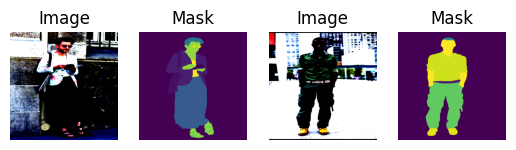

In [ ]:
for data in val_ds.take(1):
  images = data["pixel_values"]
  masks = data["labels"]
  for i in range(BATCH_SIZE*2):
    if i==4:
      break
    ax = plt.subplot(1, BATCH_SIZE*2, i+1)

    if i%2==0:
      plt.imshow(tf.transpose(images[i//2],(1, 2, 0)))
      plt.title("Image")
    else:
      plt.imshow(masks[i//2])
      plt.title("Mask")
    ax.axis("off")
  plt.show()

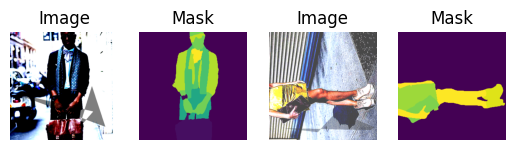

In [ ]:
for data in train_ds.take(1):
  images = data["pixel_values"]
  masks = data["labels"]
  for i in range(BATCH_SIZE*2):
    if i==4:
      break
    ax = plt.subplot(1, BATCH_SIZE*2, i+1)

    if i%2==0:
      plt.imshow(tf.transpose(images[i//2],(1, 2, 0)))
      plt.title("Image")
    else:
      plt.imshow(masks[i//2])
      plt.title("Mask")
    ax.axis("off")
  plt.show()

MODELING

In [ ]:
df = pd.read_csv("/content/dataset/labels.csv")

In [ ]:
id2label = {}
for i, j in df.iterrows():
  if i==0:
    id2label[i] = "nan"
  else:
    id2label[i] = j["label_list"]


In [ ]:
id2label[10]

'cape'

In [ ]:
label2id = { label:id for id, label in id2label.items() }

In [ ]:
print(label2id)

{'nan': 0, 'accessories': 1, 'bag': 2, 'belt': 3, 'blazer': 4, 'blouse': 5, 'bodysuit': 6, 'boots': 7, 'bra': 8, 'bracelet': 9, 'cape': 10, 'cardigan': 11, 'clogs': 12, 'coat': 13, 'dress': 14, 'earrings': 15, 'flats': 16, 'glasses': 17, 'gloves': 18, 'hair': 19, 'hat': 20, 'heels': 21, 'hoodie': 22, 'intimate': 23, 'jacket': 24, 'jeans': 25, 'jumper': 26, 'leggings': 27, 'loafers': 28, 'necklace': 29, 'panties': 30, 'pants': 31, 'pumps': 32, 'purse': 33, 'ring': 34, 'romper': 35, 'sandals': 36, 'scarf': 37, 'shirt': 38, 'shoes': 39, 'shorts': 40, 'skin': 41, 'skirt': 42, 'sneakers': 43, 'socks': 44, 'stockings': 45, 'suit': 46, 'sunglasses': 47, 'sweater': 48, 'sweatshirt': 49, 'swimwear': 50, 't-shirt': 51, 'tie': 52, 'tights': 53, 'top': 54, 'vest': 55, 'wallet': 56, 'watch': 57, 'wedges': 58}


In [ ]:
model_id = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
model = TFSegformerForSemanticSegmentation.from_pretrained(
    model_id,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
All model checkpoint layers were used when initializing TFSegformerForSemanticSegmentation.

Some weights of TFSegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidi

In [ ]:
model.summary()

Model: "tf_segformer_for_semantic_segmentation"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 segformer (TFSegformerMain  multiple                  81443008  
 Layer)                                                          
                                                                 
 decode_head (TFSegformerDe  multiple                  3197243   
 codeHead)                                                       
                                                                 
Total params: 84640251 (322.88 MB)
Trainable params: 84638715 (322.87 MB)
Non-trainable params: 1536 (6.00 KB)
_________________________________________________________________


In [ ]:
model(tf.zeros([1,3,H,W])).logits.shape

TensorShape([1, 59, 128, 128])

TRAIN MODEL AND EVALUATE

In [ ]:
import evaluate
metric = evaluate.load("mean_iou")

In [ ]:
# def compute_metrics(eval_pred):
#   logits, labels = eval_pred
#   logits = tf.transpose(logits, perm=[0,2,3,1])
#   logits_resized =tf.image.resize(
#       logits,
#       size=tf.shape(labels)[1:],
#       method="bilinear"
#   )
#   pred_labels = tf.argmax(logits_resized, axis=-1)

#   metrics = metric.compute(
#       predictions = pred_labels,
#       references = labels,
#       num_labels = len(label2id),
#       ignore_index = 0,
#   )

#   per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
#   per_category_iou = metrics.pop("per_category_iou").tolist()

#   metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
#   metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

#   return {"val_" + k: v for k, v in metrics.items()}

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  logits = tf.transpose(logits,perm=[0,2,3,1])
  logits_resized = tf.image.resize(logits, size=tf.shape(labels)[1:],method="bilinear")
  pred_labels = tf.argmax(logits_resized, axis=-1)

  metrics = metric.compute(
      predictions=pred_labels,
      references=labels,
      num_labels=len(label2id),
      ignore_index=0
  )

  per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
  per_category_iou = metrics.pop("per_category_iou").tolist()

  metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
  metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})


  return {"val_" + k: v for k, v in metrics.items()}

In [ ]:
print("Structure of train_ds:")
print(train_ds.element_spec)

print("\nStructure of val_ds:")
print(val_ds.element_spec)

Structure of train_ds:
{'pixel_values': TensorSpec(shape=(None, None, None, None), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=<unknown>, dtype=tf.float32, name=None)}

Structure of val_ds:
{'pixel_values': TensorSpec(shape=(None, None, None, None), dtype=tf.float32, name=None), 'labels': TensorSpec(shape=<unknown>, dtype=tf.float32, name=None)}


In [ ]:
batch_size = 2
num_epochs = 15
num_train_steps = len(train_ds) * num_epochs
learning_rate = 6e-5
weight_decay = 0.01

optimizers, lr_scheduler = create_optimizer(
    init_lr=learning_rate,
    weight_decay_rate=weight_decay,
    num_train_steps=num_train_steps,
    num_warmup_steps=0,
)

In [ ]:
from transformers.keras_callbacks import KerasMetricCallback

metric_callback = KerasMetricCallback(
    metric_fn=compute_metrics,
    eval_dataset=val_ds,
    batch_size=batch_size,
    label_cols=["labels"]
)
callbacks = [metric_callback]

In [ ]:
model.compile(optimizer=optimizers)

In [ ]:

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = num_epochs,
    callbacks = callbacks
)

Epoch 1/15
462/462 [==============================] - ETA: 0s - loss: 1.4285

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


462/462 [==============================] - 838s 1s/step - loss: 1.4285 - val_loss: 0.6377 - val_mean_iou: 0.0430 - val_mean_accuracy: 0.0759 - val_overall_accuracy: 0.3936 - val_accuracy_nan: nan - val_accuracy_accessories: 0.0000e+00 - val_accuracy_bag: 0.2587 - val_accuracy_belt: 0.0000e+00 - val_accuracy_blazer: 0.0000e+00 - val_accuracy_blouse: 0.0555 - val_accuracy_bodysuit: 0.0000e+00 - val_accuracy_boots: 0.0000e+00 - val_accuracy_bra: nan - val_accuracy_bracelet: 0.0000e+00 - val_accuracy_cape: 0.0000e+00 - val_accuracy_cardigan: 0.0000e+00 - val_accuracy_clogs: nan - val_accuracy_coat: 0.6407 - val_accuracy_dress: 0.7047 - val_accuracy_earrings: nan - val_accuracy_flats: 0.0000e+00 - val_accuracy_glasses: 0.0000e+00 - val_accuracy_gloves: 0.0000e+00 - val_accuracy_hair: 0.3013 - val_accuracy_hat: 0.0000e+00 - val_accuracy_heels: 0.0000e+00 - val_accuracy_hoodie: nan - val_accuracy_intimate: nan - val_accuracy_jacket: 0.0000e+00 - val_accuracy_jeans: 0.0058 - val_accuracy_jumpe

/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:259: RuntimeWarning: invalid value encountered in divide
  iou = total_area_intersect / total_area_union
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


462/462 [==============================] - 507s 1s/step - loss: 0.7894 - val_loss: 0.4966 - val_mean_iou: 0.0790 - val_mean_accuracy: 0.1275 - val_overall_accuracy: 0.4845 - val_accuracy_nan: nan - val_accuracy_accessories: 0.0000e+00 - val_accuracy_bag: 0.6965 - val_accuracy_belt: 0.0000e+00 - val_accuracy_blazer: 0.0000e+00 - val_accuracy_blouse: 0.3885 - val_accuracy_bodysuit: 0.0000e+00 - val_accuracy_boots: 0.0000e+00 - val_accuracy_bra: nan - val_accuracy_bracelet: 0.0000e+00 - val_accuracy_cape: 0.0000e+00 - val_accuracy_cardigan: 0.0000e+00 - val_accuracy_clogs: nan - val_accuracy_coat: 0.7609 - val_accuracy_dress: 0.8012 - val_accuracy_earrings: nan - val_accuracy_flats: 0.0000e+00 - val_accuracy_glasses: 0.0000e+00 - val_accuracy_gloves: 0.0000e+00 - val_accuracy_hair: 0.7363 - val_accuracy_hat: 0.0000e+00 - val_accuracy_heels: 0.0000e+00 - val_accuracy_hoodie: nan - val_accuracy_intimate: nan - val_accuracy_jacket: 0.0000e+00 - val_accuracy_jeans: 0.6786 - val_accuracy_jumpe

MODEL CHECKPOINT

In [ ]:
#checkpoint_filepath = "/content/drive/MyDrive/Model_Segmentation/segformer_b5_clothing.h5"
#model.save_weights(checkpoint_filepath)

In [ ]:
# Lấy dictionary chứa toàn bộ lịch sử các chỉ số từ biến history
hist_dict = history.history

# Chuyển đổi thành dạng bảng (DataFrame) của Pandas
hist_df = pd.DataFrame(hist_dict)

# Lưu ra file định dạng .csv
hist_df.to_csv('training_metrics.csv', index=False)

       loss  val_loss  val_mean_iou  val_mean_accuracy  val_overall_accuracy  \
0  1.428461  0.637725      0.043001           0.075917              0.393640   
1  0.789386  0.496553      0.079007           0.127511              0.484530   
2  0.676547  0.450149      0.098157           0.150351              0.519145   
3  0.617334  0.417434      0.119555           0.181682              0.530659   
4  0.569790  0.412514      0.118001           0.193554              0.521536   

   val_accuracy_nan  val_accuracy_accessories  val_accuracy_bag  \
0               NaN                       0.0          0.258727   
1               NaN                       0.0          0.696506   
2               NaN                       0.0          0.794617   
3               NaN                       0.0          0.841186   
4               NaN                       0.0          0.809490   

   val_accuracy_belt  val_accuracy_blazer  ...  val_iou_sweatshirt  \
0           0.000000             0.000000  ...

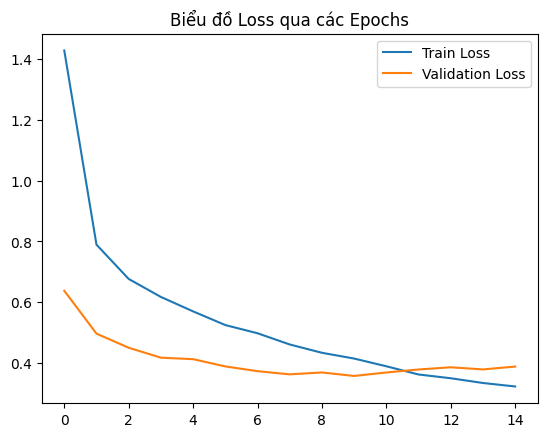

In [ ]:

# 1. Đọc lại file CSV đã lưu
history_df = pd.read_csv('training_metrics.csv')

# 2. Xem lại 5 dòng đầu tiên
print(history_df.head())

# 3. Vẽ thử biểu đồ Loss
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Biểu đồ Loss qua các Epochs')
plt.legend()
plt.show()

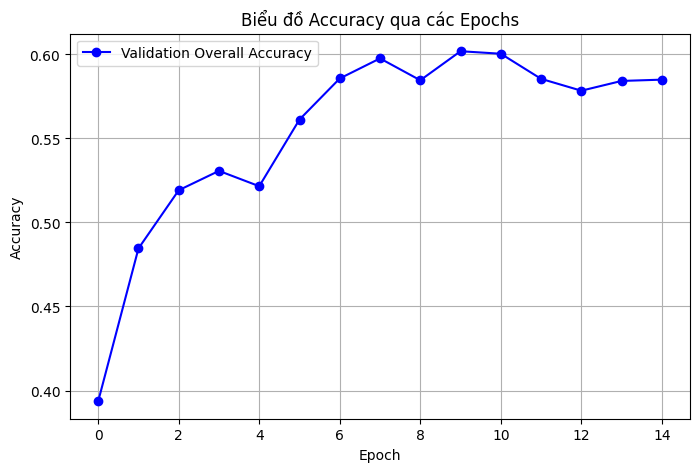

In [ ]:

# 1. Đọc lại file CSV
history_df = pd.read_csv('training_metrics.csv')

# 2. Vẽ biểu đồ Accuracy (Độ chính xác tổng thể)
plt.figure(figsize=(8, 5))
plt.plot(history_df['val_overall_accuracy'], label='Validation Overall Accuracy', color='blue', marker='o')

# (Nếu quá trình train của bạn có in ra cả 'accuracy' của tập train thì bạn bỏ comment dòng dưới)
# plt.plot(history_df['accuracy'], label='Train Accuracy', color='green', marker='s')

plt.title('Biểu đồ Accuracy qua các Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. LƯU BẢNG CHỈ SỐ (LOSS, ACCURACY, IOU...) RA FILE CSV
history_df = pd.DataFrame(history.history)
history_df.to_csv('/content/drive/MyDrive/Model_Segmentation/training_metrics.csv', index=False)

In [ ]:
# 2. LƯU BỘ NÃO CỦA MÔ HÌNH (TRỌNG SỐ)
model.save('/content/drive/MyDrive/Model_Segmentation/mo_hinh_phan_vung.keras')

LOAD MODEL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from transformers import TFSegformerForSemanticSegmentation

# Khởi tạo lại khung mô hình Segformer B5 khổng lồ
loaded_model = TFSegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b5",
    num_labels=59,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Bơm "bộ não" 15 epochs của bạn vào
loaded_model.load_weights('/content/drive/MyDrive/Model_Segmentation/mo_hinh_phan_vung.keras')

print("Phục hồi mô hình Segformer B5 thành công! Khớp 100%!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tf_model.h5:   0%|          | 0.00/329M [00:00<?, ?B/s]

Some layers from the model checkpoint at nvidia/mit-b5 were not used when initializing TFSegformerForSemanticSegmentation: ['classifier']
- This IS expected if you are initializing TFSegformerForSemanticSegmentation from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSegformerForSemanticSegmentation from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFSegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b5 and are newly initialized: ['decode_head']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Phục hồi mô hình Segformer B5 thành công! Khớp 100%!


TESTING

In [ ]:
H_resized, W_resized = 512, 512
H_init, W_init = 825,550

In [ ]:
# test_im_path = "/content/val_dataset/png_images/IMAGES/img_0003.png"

In [ ]:
test_im_path = "/content/test_segment.jpg"

In [ ]:
im_tensor = tf.io.decode_jpeg(tf.io.read_file(test_im_path))
original_img = im_tensor
im_tensor = tf.image.resize(im_tensor, (H_resized, W_resized))
im_tensor = tf.cast(im_tensor, tf.float32)
im_tensor = (im_tensor-MEAN)/STD
im_tensor = tf.transpose(im_tensor, (2, 0, 1))
im_tensor = tf.expand_dims(im_tensor, axis=0)

In [ ]:
logits = model(im_tensor).logits
print(logits.shape)

(1, 59, 128, 128)


In [ ]:
# logits = loaded_model(im_tensor).logits        # Hoặc dùng loaded_model khi load lại check point model
# print(logits.shape)

(1, 59, 128, 128)


In [ ]:
pred_labels = tf.argmax(logits, axis=1)
print(pred_labels.shape)

(1, 128, 128)


In [ ]:
print(pred_labels)

tf.Tensor(
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]], shape=(1, 128, 128), dtype=int64)


In [ ]:
resized_pred_labels = tf.image.resize(
    tf.expand_dims(pred_labels,axis=-1),
    size=(H_init, W_init),
    method="nearest"
)

In [ ]:
resized_pred_labels_np = tf.squeeze(resized_pred_labels, axis=-1)[0].numpy()

In [ ]:
print(resized_pred_labels_np)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
cmap = plt.cm.get_cmap("viridis", len(id2label))

/tmp/ipykernel_18339/2357482606.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(id2label))


In [ ]:
colored_mask = cmap(resized_pred_labels_np)

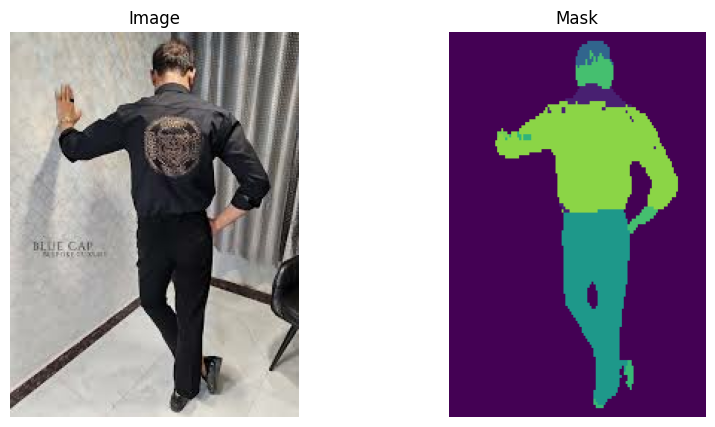

In [ ]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(colored_mask)
plt.title("Mask")
plt.axis("off")
plt.show()

In [ ]:
def generate_inputs(im_path, mask_label):
  mask_id = label2id[mask_label]
  source_image = cv2.imread(im_path)

  img = tf.io.decode_jpeg(tf.io.read_file(im_path))
  img = tf.image.resize(img, (H_resized, W_resized))
  img = tf.cast(img, tf.float32)
  img = (img-MEAN)/STD
  img = tf.transpose(img, (2,0,1))
  img = tf.expand_dims(img, axis=0)

  output = model(img).logits

  output = tf.argmax(output, axis=1)

  resized_output = tf.image.resize(
      tf.expand_dims(output,axis=-1),(H_init, W_init), method="bilinear", antialias=True)

  # Cast to a signed integer type (e.g., tf.int32) before converting to numpy
  # to allow for negative values during subtraction without overflow.
  resized_output_int = tf.cast(tf.squeeze(resized_output, axis=-1),dtype=tf.int32)[0].numpy()

  # Perform subtraction with the int32 numpy array
  mask_diff = resized_output_int - mask_id

  # The rest of the logic to create a binary mask (255 for mask_id, 0 otherwise)
  mask = 255 - np.clip(1e10 * np.multiply(mask_diff, mask_diff), a_min=0, a_max=255)
  cv2.imwrite("mask.jpg", mask)

  return Image.fromarray(source_image), Image.fromarray(mask)

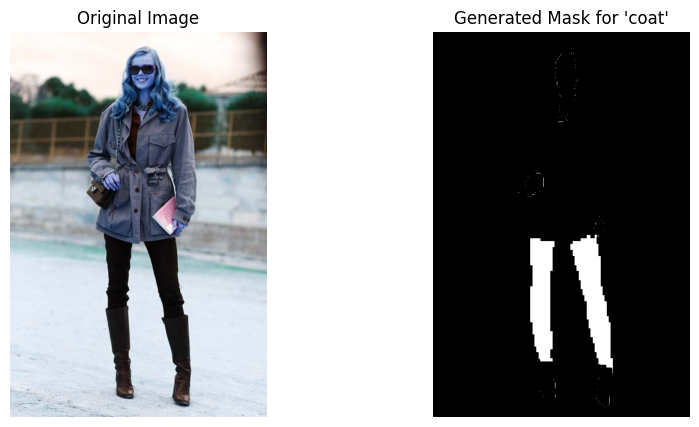

In [ ]:
image, mask_image = generate_inputs(
    "/content/val_dataset/png_images/IMAGES/img_0003.png", "jeans"
)

# Display the original image and the generated mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_image, cmap='gray')
plt.title("Generated Mask for 'coat'")
plt.axis("off")

plt.show()